# Regression and Regularization

**Course Title:** ENM 3800: Learning from Data

**Instructor:** Eva Dyer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_4/Notebook_4a_Regression.ipynb)

Regression models predict continuous outcomes. In this notebook, we use the diabetes dataset to study:

- linear regression with one feature and many features,
- residuals and error metrics,
- model coefficients as learned feature weights,
- ridge, lasso, and elastic-net regularization,
- robust regression with RANSAC.

Big theme:

> Regression is not only about fitting a line. It is about understanding prediction error, feature contributions, and how regularization changes what a model is allowed to learn.


In this lecture, we will study:

* least-squares regression,
* ridge regression,
* sparse regression (LASSO)

#### Dataset

<p><strong>Diabetes Data Set Characteristics:</strong></p>

<p>Ten baseline variables, age, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
*quantitative measure of disease progression one year after baseline*.</p>


<div><dl class="field-list simple">
<dt class="field-odd">Number of Instances</dt>
<dd class="field-odd"><p>442</p>
</dd>
<dt class="field-even">Number of Attributes</dt>
<dd class="field-even"><p>First 10 columns are numeric predictive values</p>
</dd>
<dt class="field-odd">Target</dt>
<dd class="field-odd"><p>Column 11 is a quantitative measure of disease progression one year after baseline</p>
</dd>
<dt class="field-even">Attribute Information</dt>


*   **age** - age in years
*   **sex** - discrete variable
* **bmi** - body mass index
*  **bp** - average blood pressure
* **tc** - (s1) total serum cholesterol
* **ldl** - (s2) low-density lipoproteins
* **hdl** - (s3) high-density lipoproteins
* **tch** - (s4) total cholesterol / HDL
* **ltg** - (s5) possibly log of serum triglycerides level
* **glu** - (s6) blood sugar level

<p>Note: Each of these 10 feature variables have been mean centered and scaled by the standard deviation times <code class="docutils literal notranslate"><span class="pre">n_samples</span></code> (i.e. the sum of squares of each column totals 1).</p>
<p>Source URL:
<a class="reference external" href="https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html">https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html</a></p>
<p>For more information see:
Bradley Efron, Trevor Hastie, Iain Johnstone and Robert Tibshirani (2004) “Least Angle Regression,” Annals of Statistics (with discussion), 407-499.
(<a class="reference external" href="https://web.stanford.edu/~hastie/Papers/LARS/LeastAngle_2002.pdf">https://web.stanford.edu/~hastie/Papers/LARS/LeastAngle_2002.pdf</a>)</p>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model

diabetes = datasets.load_diabetes()

### Visualization Helpers for Regression

These helper functions will let us inspect predictions, residuals, and coefficient behavior across models.


In [2]:
#| code-fold: true
def plot_predicted_vs_actual(y_true, y_pred, title="Predicted vs Actual"):
    plt.figure(figsize=(5.5, 5.5))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolor="black")
    lo = min(np.min(y_true), np.min(y_pred))
    hi = max(np.max(y_true), np.max(y_pred))
    plt.plot(
        [lo, hi], [lo, hi], color="crimson", linestyle="--", label="perfect prediction"
    )
    plt.xlabel("actual target")
    plt.ylabel("predicted target")
    plt.title(title)
    plt.legend()
    plt.show()


def plot_residuals(y_true, y_pred, title="Residual Diagnostics"):
    residuals = y_true - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].scatter(y_pred, residuals, alpha=0.7, edgecolor="black")
    axes[0].axhline(0, color="crimson", linestyle="--")
    axes[0].set_xlabel("predicted target")
    axes[0].set_ylabel("residual = actual - predicted")
    axes[0].set_title("Residuals vs Predictions")

    sns.histplot(residuals, kde=True, ax=axes[1])
    axes[1].axvline(0, color="crimson", linestyle="--")
    axes[1].set_title("Residual Distribution")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_coefficients(coefs, names, title="Model Coefficients"):
    order = np.argsort(np.abs(coefs))
    plt.figure(figsize=(8, 5))
    plt.barh(np.array(names)[order], np.array(coefs)[order])
    plt.axvline(0, color="black", linewidth=1)
    plt.title(title)
    plt.xlabel("coefficient value")
    plt.show()

In [3]:
feature_names = diabetes["feature_names"]
X = diabetes["data"]
y = diabetes["target"]

print("Feature names:", feature_names)
print("Number of samples:", X.shape[0])

Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Number of samples: 442


**Splitting the dataset into a train and test set**

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

#### Least-squares regression

Linear Regression fits a linear model with coefficients
 to minimize the residual sum of squares between the observed targets in the dataset, and the targets predicted by the linear approximation. Mathematically it solves a problem of the form:

 $$\min_{\beta} || X \beta - y||_2^2$$

 In a previous lecture we saw how to derive the LS estimator:

$$\widehat{\beta} = (X^T X)^{+}X^T y$$


##### 2.1. Fit the model to a single feature

We're already familiar with `sklearn` API. We can use the `LinearRegression` class to define parameters, fit training data and predict a measure of the disease progress. To begin, we can *fit the model to a single feature*, the BMI.


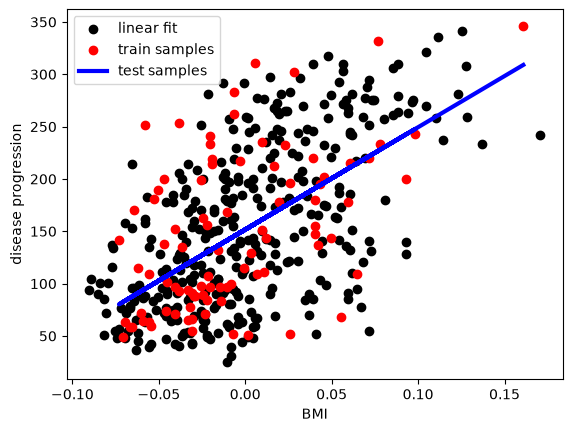

In [5]:
bmi_train = X_train[:, 2:3]
bmi_test = X_test[:, 2:3]

# create linear regression object
regr = linear_model.LinearRegression()

# fit training samples
regr.fit(bmi_train, y_train)

# predict on test samples
y_test_pred = regr.predict(bmi_test)

plt.scatter(bmi_train, y_train, color="black")
plt.scatter(bmi_test, y_test, color="red")
plt.plot(bmi_test, y_test_pred, color="blue", linewidth=3)
plt.xlabel("BMI")
plt.ylabel("disease progression")
plt.legend(["linear fit", "train samples", "test samples"])
plt.show()

**Model details:**

This linear model deals with one feature only, it has the following equation:
$$\hat y(x) = a x + b$$

When `.fit` is called, the model will find the slope $a$ and the intercept $b$ that minimize the squared error over the training samples.

The parameters are saved in the `regr` object as attributes `coef_` and `intercept_` for $a$ and $b$ respectively.

In [6]:
print("Slope: %.2f" % regr.coef_[0])
print("Intercept: %.2f" % regr.intercept_)

Slope: 977.74
Intercept: 151.67


##### 2.2. Accuracy measures

The linear regression model is now fit to the data. It can be used on any sample to predict the corresponding $y$, using `.predict()`

We can compute the **mean squared error** or the **coefficient of determination** on the training set and the testing set.

Recall that the coefficient of determination or the $R^2$ is defined as:
$$ R^2 = 1 - \frac{\sum_{i} (y_i - \widehat{y}_i)^2}{\sum_{i} (y_i - \bar{y})^2},$$
where $\bar{y} = \frac{1}{n} \sum_{i=1}^{n} y_i$ and $\widehat{y}_i$ is the prediction for the $i^{\rm th}$ sample.


In [7]:
from sklearn.metrics import mean_squared_error, r2_score

# Metrics on the training set
y_train_pred = regr.predict(bmi_train)
print("Train set: mean squared error: %.2f" % mean_squared_error(y_train, y_train_pred))
print("Train set: coefficient of determination: %.2f" % r2_score(y_train, y_train_pred))

# Metrics on the test set
y_test_pred = regr.predict(bmi_test)
print("Test set: mean squared error: %.2f" % mean_squared_error(y_test, y_test_pred))
print("Test set: coefficient of determination: %.2f" % r2_score(y_test, y_test_pred))

Train set: mean squared error: 3867.94
Train set: coefficient of determination: 0.36
Test set: mean squared error: 3989.83
Test set: coefficient of determination: 0.25


#### Least-squares (Multi-features)

We find that the linear model doesn't perform well on the test set. While this indicates that the model does not generalize well yet. To improve the performance of our predictive model, we can use all of the features we have at our disposal.



##### 3.1 Take a closer look at the features


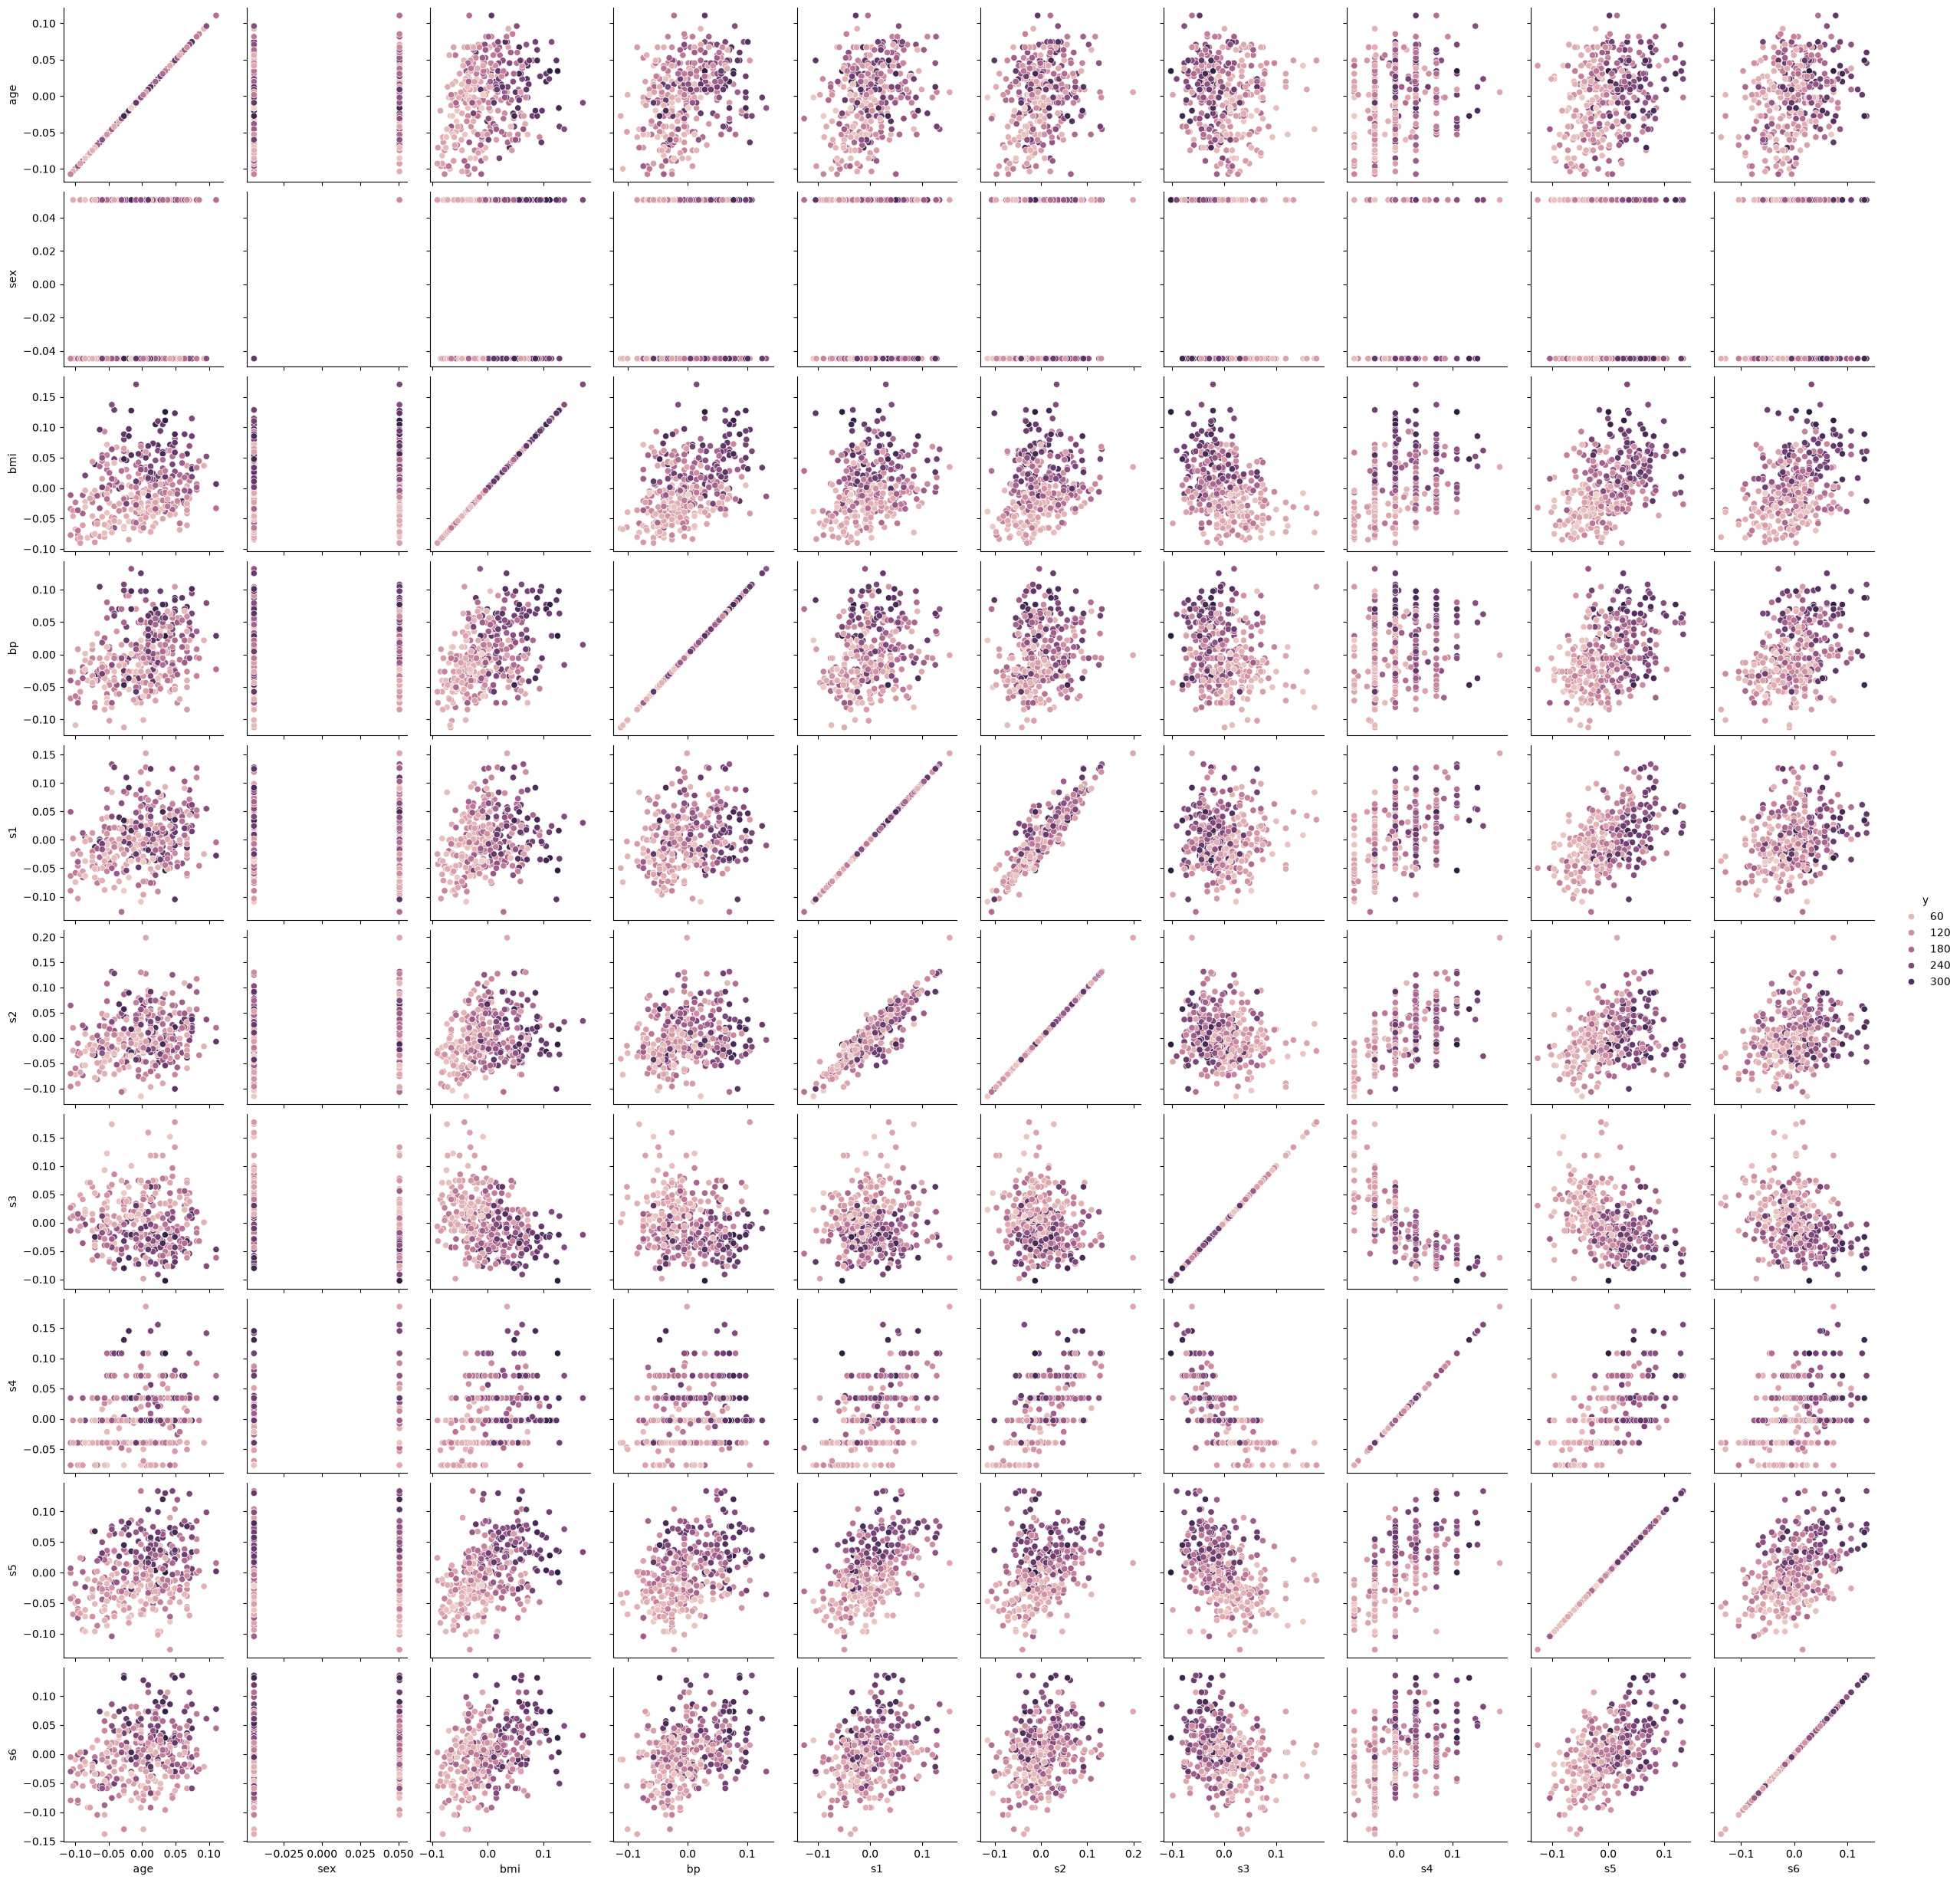

In [8]:
import pandas as pd
import seaborn as sns

df = pd.DataFrame(
    np.hstack([X_train, y_train[:, np.newaxis]]), columns=feature_names + ["y"]
)
sns.pairplot(df, hue="y", diag_kind=None)

##### 3.2. Fit a linear regression model to all features

In [9]:
# create linear regression object
regr = linear_model.LinearRegression()

# fit training samples
regr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ -30.62,-272.25, 528.85,..., 139.28, 665.08, 61.91]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,151.4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,10
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[1.8 ,1.11,0.98,...,0.58,0.25,0.08]"


In [10]:
y_train_pred = regr.predict(X_train)
print("Train set: mean squared error: %.2f" % mean_squared_error(y_train, y_train_pred))
print("Train set: coefficient of determination: %.2f" % r2_score(y_train, y_train_pred))

y_test_pred = regr.predict(X_test)
print("Test set: mean squared error: %.2f" % mean_squared_error(y_test, y_test_pred))
print("Test set: coefficient of determination: %.2f" % r2_score(y_test, y_test_pred))

Train set: mean squared error: 2835.04
Train set: coefficient of determination: 0.53
Test set: mean squared error: 2992.58
Test set: coefficient of determination: 0.44


### Visual Diagnostic: Residuals

A single error number is useful, but it hides *where* the model is wrong.

Residual plots help us ask:

- Are errors centered around zero?
- Are errors larger for high or low predictions?
- Are there outliers?
- Is the model missing nonlinear structure?


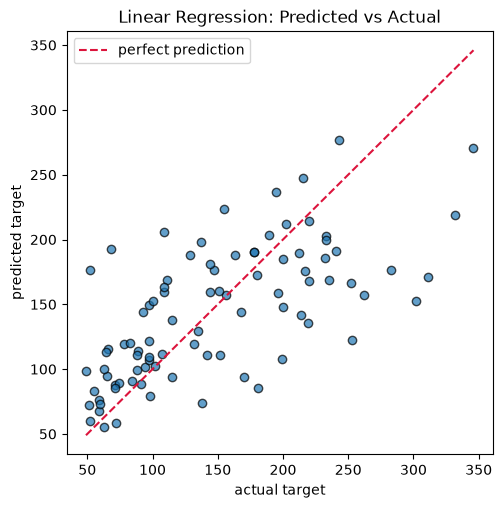

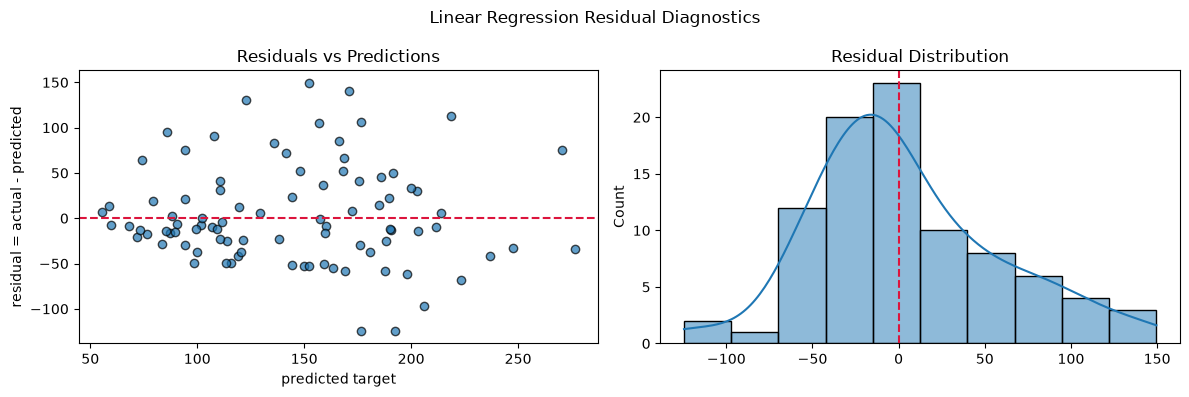

In [11]:
plot_predicted_vs_actual(
    y_test, y_test_pred, title="Linear Regression: Predicted vs Actual"
)
plot_residuals(y_test, y_test_pred, title="Linear Regression Residual Diagnostics")

#### Exercise: Read the Residual Plot

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_4/Notebook_4a_Regression.ipynb#scrollTo=ex-read-residual-plot)

1. Are residuals mostly centered around zero?
2. Are large target values predicted well or poorly?
3. Do you see any outliers?
4. What might a pattern in the residuals suggest about the model?


##### 3.3. The performance of the model increased. Let's take a look at the weights assigned to each feature:

Intercept: 151.43


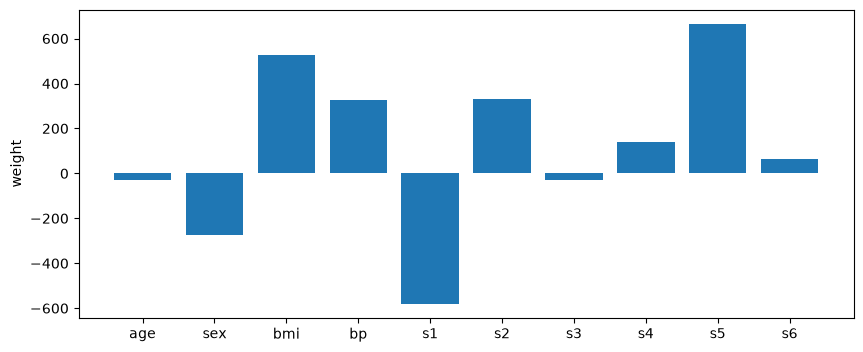

In [12]:
#| code-fold: true
plt.figure(figsize=(10, 4))
plt.bar(feature_names, regr.coef_)
plt.ylabel("weight")
print("Intercept: %.2f" % regr.intercept_)

#### Ridge Regression

$$\min_{\beta} || X \beta - y||_2^2 + \alpha ||\beta||_2^2$$

The hyperparameter  $\alpha$ controls the amount of shrinkage: the larger the value of $\alpha$, the greater the amount of shrinkage and thus the coefficients become more robust to collinearity.


##### 4.1 Apply ridge to diabetes dataset

Now let's apply the ridge estimator to our data from before.

In [13]:
regr = linear_model.Ridge(alpha=0.5)

# fit training samples
regr.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [14]:
y_train_pred = regr.predict(X_train)
print("Train set: mean squared error: %.2f" % mean_squared_error(y_train, y_train_pred))
print("Train set: coefficient of determination: %.2f" % r2_score(y_train, y_train_pred))

y_test_pred = regr.predict(X_test)
print("Test set: mean squared error: %.2f" % mean_squared_error(y_test, y_test_pred))
print("Test set: coefficient of determination: %.2f" % r2_score(y_test, y_test_pred))

Train set: mean squared error: 3064.63
Train set: coefficient of determination: 0.50
Test set: mean squared error: 3106.27
Test set: coefficient of determination: 0.42


##### 4.2. What happens as we increase the amount of regularization?

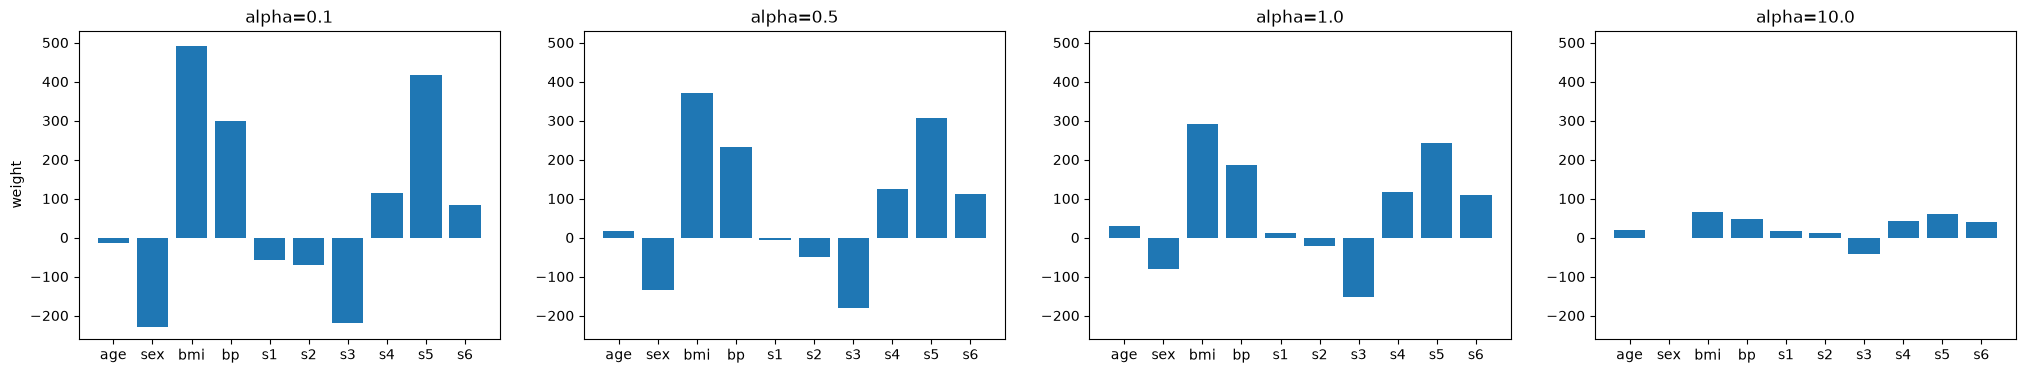

In [15]:
fig, axs = plt.subplots(1, 4, figsize=(25, 4))

for i, alpha in enumerate([0.1, 0.5, 1.0, 10.0]):
    regr = linear_model.Ridge(alpha=alpha)
    regr.fit(X_train, y_train)

    axs[i].bar(feature_names, regr.coef_)
    axs[i].set_ylim([-260, 530])
    axs[i].set_title("alpha=%.1f" % alpha)
axs[0].set_ylabel("weight")
plt.show()

### Lasso

Instead of regularizing with the L2-norm, we can use other p-norms. When we use the L1-norm, this regularized estimator is called the LASSO (or Basis Pursuit Denoising, BPDN).

$$\min_{\beta} \frac{1}{2}||X \beta - y||_2 ^ 2 + \lambda ||\beta ||_1$$

##### 5.1 Apply LASSO to diabetes data

In [16]:
regr = linear_model.Lasso(alpha=0.5)

# fit training samples
regr.fit(X_train, y_train)

y_train_pred = regr.predict(X_train)
print("Train set: mean squared error: %.2f" % mean_squared_error(y_train, y_train_pred))
print("Train set: coefficient of determination: %.2f" % r2_score(y_train, y_train_pred))

y_test_pred = regr.predict(X_test)
print("Test set: mean squared error: %.2f" % mean_squared_error(y_test, y_test_pred))
print("Test set: coefficient of determination: %.2f" % r2_score(y_test, y_test_pred))

Train set: mean squared error: 3216.75
Train set: coefficient of determination: 0.47
Test set: mean squared error: 3179.05
Test set: coefficient of determination: 0.40


##### 5.2. Varying regularization strength

Let's examine the impact of regularization on the coefficients obtained via the LASSO.

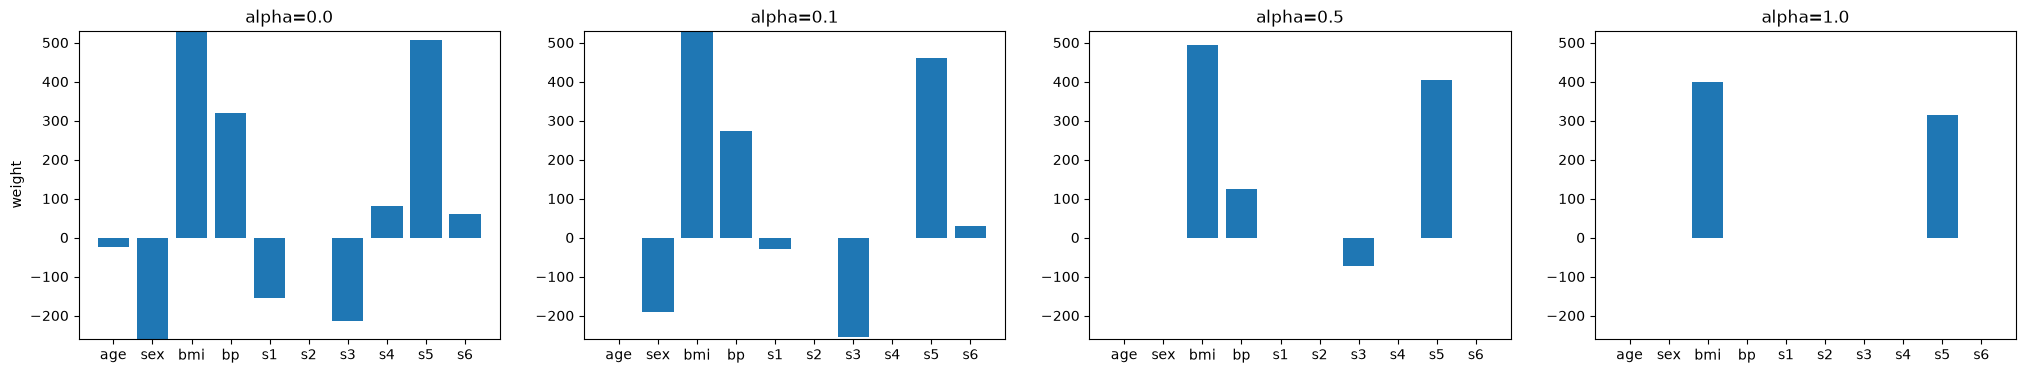

In [17]:
fig, axs = plt.subplots(1, 4, figsize=(25, 4))

for i, alpha in enumerate([0.01, 0.1, 0.5, 1.0]):
    regr = linear_model.Lasso(alpha=alpha)
    regr.fit(X_train, y_train)

    axs[i].bar(feature_names, regr.coef_)
    axs[i].set_ylim([-260, 530])
    axs[i].set_title("alpha=%.1f" % alpha)
axs[0].set_ylabel("weight")
plt.show()

**Challenge:** How does this picture look different from what we saw in ridge regression?

`
Please provide your reply here.
`


### Visualizing Regularization Paths

Regularization changes the learned coefficients.

- Ridge shrinks coefficients smoothly toward zero.
- Lasso can shrink some coefficients exactly to zero, performing feature selection.

The next visualization shows how coefficients change as the regularization strength `alpha` increases.


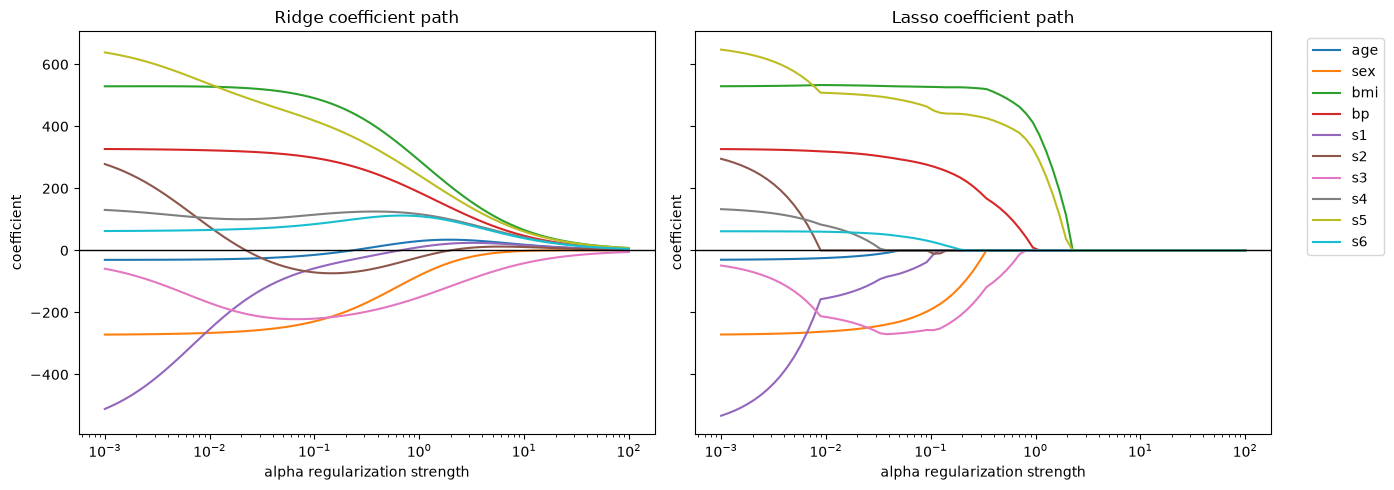

In [18]:
from sklearn.linear_model import Lasso, Ridge

alphas = np.logspace(-3, 2, 80)
ridge_coefs = []
lasso_coefs = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha, max_iter=10000)
    ridge.fit(X_train, y_train)
    ridge_coefs.append(ridge.coef_)

    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train, y_train)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for j, name in enumerate(feature_names):
    axes[0].plot(alphas, ridge_coefs[:, j], label=name)
    axes[1].plot(alphas, lasso_coefs[:, j], label=name)

for ax, title in zip(axes, ["Ridge coefficient path", "Lasso coefficient path"]):
    ax.set_xscale("log")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_xlabel("alpha regularization strength")
    ax.set_ylabel("coefficient")
    ax.set_title(title)

axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### Exercise: Compare Ridge and Lasso

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_4/Notebook_4a_Regression.ipynb#scrollTo=ex-compare-ridge-lasso)

1. Which method sets coefficients exactly to zero?
2. Which coefficients survive longest as `alpha` increases?
3. Why might sparse coefficients be easier to interpret?
4. Why might too much regularization underfit?


### Elastic-Net

In elastic net regularization, the penalty term is a linear combination of the L1 and L2 penalties:

$$ ||X \beta - y||_2 ^ 2 + \alpha \rho ||\beta||_1 +
\frac{\alpha(1-\rho)}{2} ||\beta||_2 ^ 2 $$

5.1 Implementing elastic net

In `scikit-learn`, $\rho$ is controlled by the 'l1_ratio' parameter: An 'l1_ratio' of 1 corresponds to an L1 penalty, and anything lower is a combination of L1 and L2. When you set the ratio to zero, you get ridge regression.

In [19]:
regr = linear_model.ElasticNet(alpha=0.05, l1_ratio=0.8)

# fit training samples
regr.fit(X_train, y_train)

y_train_pred = regr.predict(X_train)
print("Train set: mean squared error: %.2f" % mean_squared_error(y_train, y_train_pred))
print("Train set: coefficient of determination: %.2f" % r2_score(y_train, y_train_pred))

y_test_pred = regr.predict(X_test)
print("Test set: mean squared error: %.2f" % mean_squared_error(y_test, y_test_pred))
print("Test set: coefficient of determination: %.2f" % r2_score(y_test, y_test_pred))

Train set: mean squared error: 4236.27
Train set: coefficient of determination: 0.30
Test set: mean squared error: 3907.47
Test set: coefficient of determination: 0.27


5.2 Cross-validation for model selection

Tuning these hyperparameters can get tricky, we can use the cross-validation strategy to identify the best set of parameters

The class `ElasticNetCV` can be used to set the parameters alpha and l1_ratio by cross-validation.

In [20]:
# cross-validation for hyperparameter selection
regr = linear_model.ElasticNetCV(
    cv=5, random_state=1, l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1]
)

3. Fit model with selected hyperparameters

In [21]:
# fit training samples
regr.fit(X_train, y_train)

y_train_pred = regr.predict(X_train)
print("Train set: mean squared error: %.2f" % mean_squared_error(y_train, y_train_pred))
print("Train set: coefficient of determination: %.2f" % r2_score(y_train, y_train_pred))

y_test_pred = regr.predict(X_test)
print("Test set: mean squared error: %.2f" % mean_squared_error(y_test, y_test_pred))
print("Test set: coefficient of determination: %.2f" % r2_score(y_test, y_test_pred))

Train set: mean squared error: 2862.16
Train set: coefficient of determination: 0.53
Test set: mean squared error: 3022.33
Test set: coefficient of determination: 0.43


The optimal hyperparameters found for this model were:

In [22]:
print("alpha:", regr.alpha_)
print("l1_ratio:", regr.l1_ratio_)

alpha: 0.00511618690573813
l1_ratio: 0.95


Which values did we search over?

In [23]:
regr

,"l1_ratio l1_ratio: float or list of float, default=0.5Float between 0 and 1 passed to ElasticNet (scaling betweenl1 and l2 penalties). For ``l1_ratio = 0``the penalty is an L2 penalty. For ``l1_ratio = 1`` it is an L1 penalty.For ``0 < l1_ratio < 1``, the penalty is a combination of L1 and L2This parameter can be a list, in which case the differentvalues are tested by cross-validation and the one giving the bestprediction score is used. Note that a good choice of list ofvalues for l1_ratio is often to put more values close to 1(i.e. Lasso) and less close to 0 (i.e. Ridge), as in ``[.1, .5, .7,.9, .95, .99, 1]``.","[0.1, 0.5, ...]"
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",1
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"alphas alphas: array-like or int, default=100Values of alphas to test along the regularization path, used for each l1_ratio.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`.",100
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"verbose verbose: bool or int, default=0Amount of verbosity.",0


### Why Robust Regression?

Least-squares regression can be strongly affected by outliers because squared error gives very large penalties to large residuals.

RANSAC tries to fit a model using a subset of points that appear consistent, while treating unusual points as possible outliers.


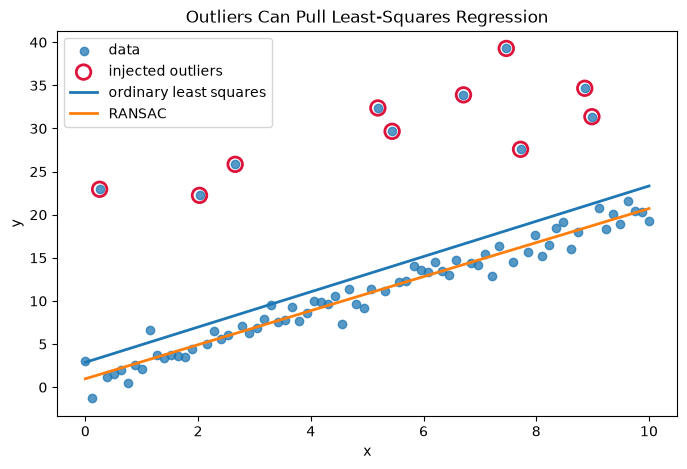

In [24]:
from sklearn.linear_model import LinearRegression, RANSACRegressor

rng = np.random.default_rng(3)
x_demo = np.linspace(0, 10, 80)
y_demo = 2.0 * x_demo + 1.0 + rng.normal(0, 1.0, size=len(x_demo))

# Add outliers
outlier_idx = rng.choice(len(x_demo), size=10, replace=False)
y_demo[outlier_idx] += rng.normal(18, 4, size=len(outlier_idx))

X_demo = x_demo.reshape(-1, 1)
ols = LinearRegression().fit(X_demo, y_demo)
ransac = RANSACRegressor(LinearRegression(), random_state=0).fit(X_demo, y_demo)

x_grid = np.linspace(0, 10, 200).reshape(-1, 1)

plt.figure(figsize=(8, 5))
plt.scatter(x_demo, y_demo, alpha=0.75, label="data")
plt.scatter(
    x_demo[outlier_idx],
    y_demo[outlier_idx],
    facecolor="none",
    edgecolor="crimson",
    s=110,
    linewidth=2,
    label="injected outliers",
)
plt.plot(x_grid, ols.predict(x_grid), label="ordinary least squares", linewidth=2)
plt.plot(x_grid, ransac.predict(x_grid), label="RANSAC", linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Outliers Can Pull Least-Squares Regression")
plt.legend()
plt.show()

### RANSAC: RANdom SAmple Consensus

RANSAC consists of the following steps:

1. Fit a model to **min_samples random samples** from the original data (base_estimator.fit).

2. Classify all data as inliers or outliers by calculating the residuals to the estimated model (base_estimator.predict(X) - y) - **all data samples with absolute residuals smaller than the residual_threshold are considered as inliers**.

3. Save fitted model as **best model if number of inlier samples is maximal**. If the current estimated model has the same number of inliers, it is only considered as the best model if it has better score.

These steps are performed either a maximum number of times (max_trials) or until one of the special stop criteria are met (see stop_n_inliers and stop_score). **The final model is estimated using all inlier samples (consensus set) of the previously determined best model.**


In [25]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn import datasets, linear_model

n_samples = 1000
n_outliers = 50

X, y, coef = datasets.make_regression(
    n_samples=n_samples,
    n_features=1,
    n_informative=1,
    noise=10,
    coef=True,
    random_state=0,
)

# Add outlier data
np.random.seed(0)
X[:n_outliers] = 3 + 0.5 * np.random.normal(size=(n_outliers, 1))
y[:n_outliers] = -3 + 10 * np.random.normal(size=n_outliers)

# Fit line using all data
lr = linear_model.LinearRegression()
lr.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[54.17]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-9.366
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[37.42]


In [26]:
# Robustly fit linear model with RANSAC algorithm
ransac = linear_model.RANSACRegressor()
ransac.fit(X, y)
inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)

# Predict data of estimated models
line_X = np.arange(X.min(), X.max())[:, np.newaxis]
line_y = lr.predict(line_X)
line_y_ransac = ransac.predict(line_X)

Estimated coefficients (true, linear regression, RANSAC):
82.1903908407869 [54.17236387] [82.08533159]


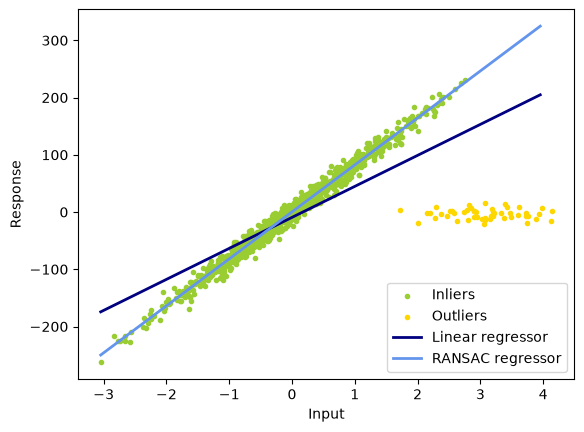

In [27]:
# Compare estimated coefficients
print("Estimated coefficients (true, linear regression, RANSAC):")
print(coef, lr.coef_, ransac.estimator_.coef_)

lw = 2
plt.scatter(
    X[inlier_mask], y[inlier_mask], color="yellowgreen", marker=".", label="Inliers"
)
plt.scatter(
    X[outlier_mask], y[outlier_mask], color="gold", marker=".", label="Outliers"
)
plt.plot(line_X, line_y, color="navy", linewidth=lw, label="Linear regressor")
plt.plot(
    line_X,
    line_y_ransac,
    color="cornflowerblue",
    linewidth=lw,
    label="RANSAC regressor",
)
plt.legend(loc="lower right")
plt.xlabel("Input")
plt.ylabel("Response")
plt.show()

**Challenge:**

- Build at least 4 different regression models for the diabetes dataset using sklearn. You can use any of the [linear models in sklearn](https://https://scikit-learn.org/stable/modules/linear_model.html), polynomial regression, or other regression models you find in sklearn. Report their accuracy on the same training, validation, and test set.

- Then, visualize the accuracy of your models as a barplot, with 3 different *subfigures* for the accuracy on your (a) training, (b) validation, and (c) test data.

- Add a text block discussing your results, and whether the models are under- or over-fitting. Go back to the pairplot or other visualizations to make sense of your results.


In [28]:
# add code here
#

**Tutorials and related concepts in sklearn:**


* Orthogonal matching pursuit (OMP) - https://scikit-learn.org/stable/modules/linear_model.html#orthogonal-matching-pursuit-omp
* Kernel ridge regression - https://scikit-learn.org/stable/modules/kernel_ridge.html
*   Linear regressors - https://scikit-learn.org/stable/modules/classes.html#classical-linear-regressors
*   Regressors with variable selection - https://scikit-learn.org/stable/modules/classes.html#regressors-with-variable-selection
* Multitask regressors - https://scikit-learn.org/stable/modules/classes.html#multi-task-linear-regressors-with-variable-selection
* Outlier-robust regressors - https://scikit-learn.org/stable/modules/classes.html#multi-task-linear-regressors-with-variable-selection



Contributors: Mehdi Azabou, Eva Dyer